In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

In [89]:
df=pd.read_csv(r"C:\Users\aksha\Downloads\kidney_disease.csv")
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [90]:
df.shape


(400, 26)

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [92]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,400.0,199.500000,115.614301,0.000,99.75,199.50,299.25,399.000
age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
bp,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
sg,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
al,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
su,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
bgr,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
bu,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
sc,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
sod,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000


In [93]:
df.dtypes

id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

In [94]:
for i in df.columns:
    print(f"**********************************************************************{i}**********************************************************************")
    print()
    print(set(df[i].tolist()))
    print()

**********************************************************************id**********************************************************************

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 

In [95]:
df['pcv'] = df['pcv'].apply(lambda x:'43' if x=='\t43' else x)
df['pcv'] = df['pcv'].apply(lambda x:'41' if x=='\t?' else x)

In [96]:
df['wc'] = df['wc'].apply(lambda x:'6200' if x=='\t6200' else x)
df['wc'] = df['wc'].apply(lambda x:'8400' if x=='\t8400' else x)
df['wc'] = df['wc'].apply(lambda x:'9800' if x=='\t?' else x)

In [97]:
df['pcv'].mode()[0]

'41'

In [98]:
df['rc'].mode()[0]

'5.2'

In [99]:
df['rc'] = df['rc'].apply(lambda x:'5.2' if x=='\t?' else x)

In [100]:
df['classification'] = df['classification'].apply(lambda x:'ckd' if x=='ckd\t' else x)

In [101]:
df['cad'] = df['cad'].apply(lambda x:'no' if x=='\tno' else x)

In [102]:
df['dm'] = df['dm'].apply(lambda x:'yes' if x=='\tyes' else x)
df['dm'] = df['dm'].apply(lambda x:'no' if x=='\tno' else x)
df['dm'] = df['dm'].apply(lambda x:'yes' if x==' yes' else x)

In [103]:
# Identify the columns to convert
numeric_cols = df.select_dtypes(exclude=["object"]).columns

# Convert all of them at once
df[numeric_cols] = df[numeric_cols].astype(float)

In [104]:
df.dtypes

id                float64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

In [105]:
for i in df.columns:
    print(f"**********************************************************************{i}**********************************************************************")
    print()
    print(set(df[i].tolist()))
    print()

**********************************************************************id**********************************************************************

{0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0, 101.0, 102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 120.0, 121.0, 122.0, 123.0, 124.0, 125.0, 126.0, 127.0, 128.0, 129.0, 130.0, 131.0, 132.0, 133.0, 134.0, 135.0, 136.0, 137.0,

In [106]:
df['pcv'] = df['pcv'].fillna(df['pcv'].mode()[0])
df['wc'] = df['wc'].fillna(df['wc'].mode()[0])
df['rc'] = df['rc'].fillna(df['rc'].mode()[0])

In [107]:
df['pcv'] = df['pcv'].astype('int64')
df['wc'] = df['wc'].astype('int64')
df['rc'] = df['rc'].astype('float64')

In [108]:
object_columns=df.select_dtypes(include=['object']).columns
object_columns

Index(['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane',
       'classification'],
      dtype='object')

In [109]:
numeric_columns=df.select_dtypes(include=['int64','float64']).columns
numeric_columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot',
       'hemo', 'pcv', 'wc', 'rc'],
      dtype='object')

In [110]:
from sklearn.impute import SimpleImputer

col_imp_model=SimpleImputer(missing_values=np.nan,strategy='most_frequent')
row_imp_model=SimpleImputer(missing_values=np.nan,strategy='median')

df_cols=pd.DataFrame(col_imp_model.fit_transform(df[object_columns]),columns=object_columns)
df_row=pd.DataFrame(row_imp_model.fit_transform(df[numeric_columns]),columns=numeric_columns)

In [111]:
df_cols.isnull().sum()

rbc               0
pc                0
pcc               0
ba                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

In [112]:
df_row.isnull().sum()

id      0
age     0
bp      0
sg      0
al      0
su      0
bgr     0
bu      0
sc      0
sod     0
pot     0
hemo    0
pcv     0
wc      0
rc      0
dtype: int64

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

def boxplot(df):
    columns=df.columns
    n = len(columns)
    cols_per_row = 3
    rows = math.ceil(n / cols_per_row)
    plt.figure(figsize=(15,15))  # width = 3 plots, height = rows
    
    for i, col in enumerate(columns):
        plt.subplot(rows, cols_per_row, i+1)
        sns.boxplot(y=df[col])
        plt.title(f"{col}")
    
    plt.suptitle("Boxplot Distribution", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
    plt.show()

# Usage



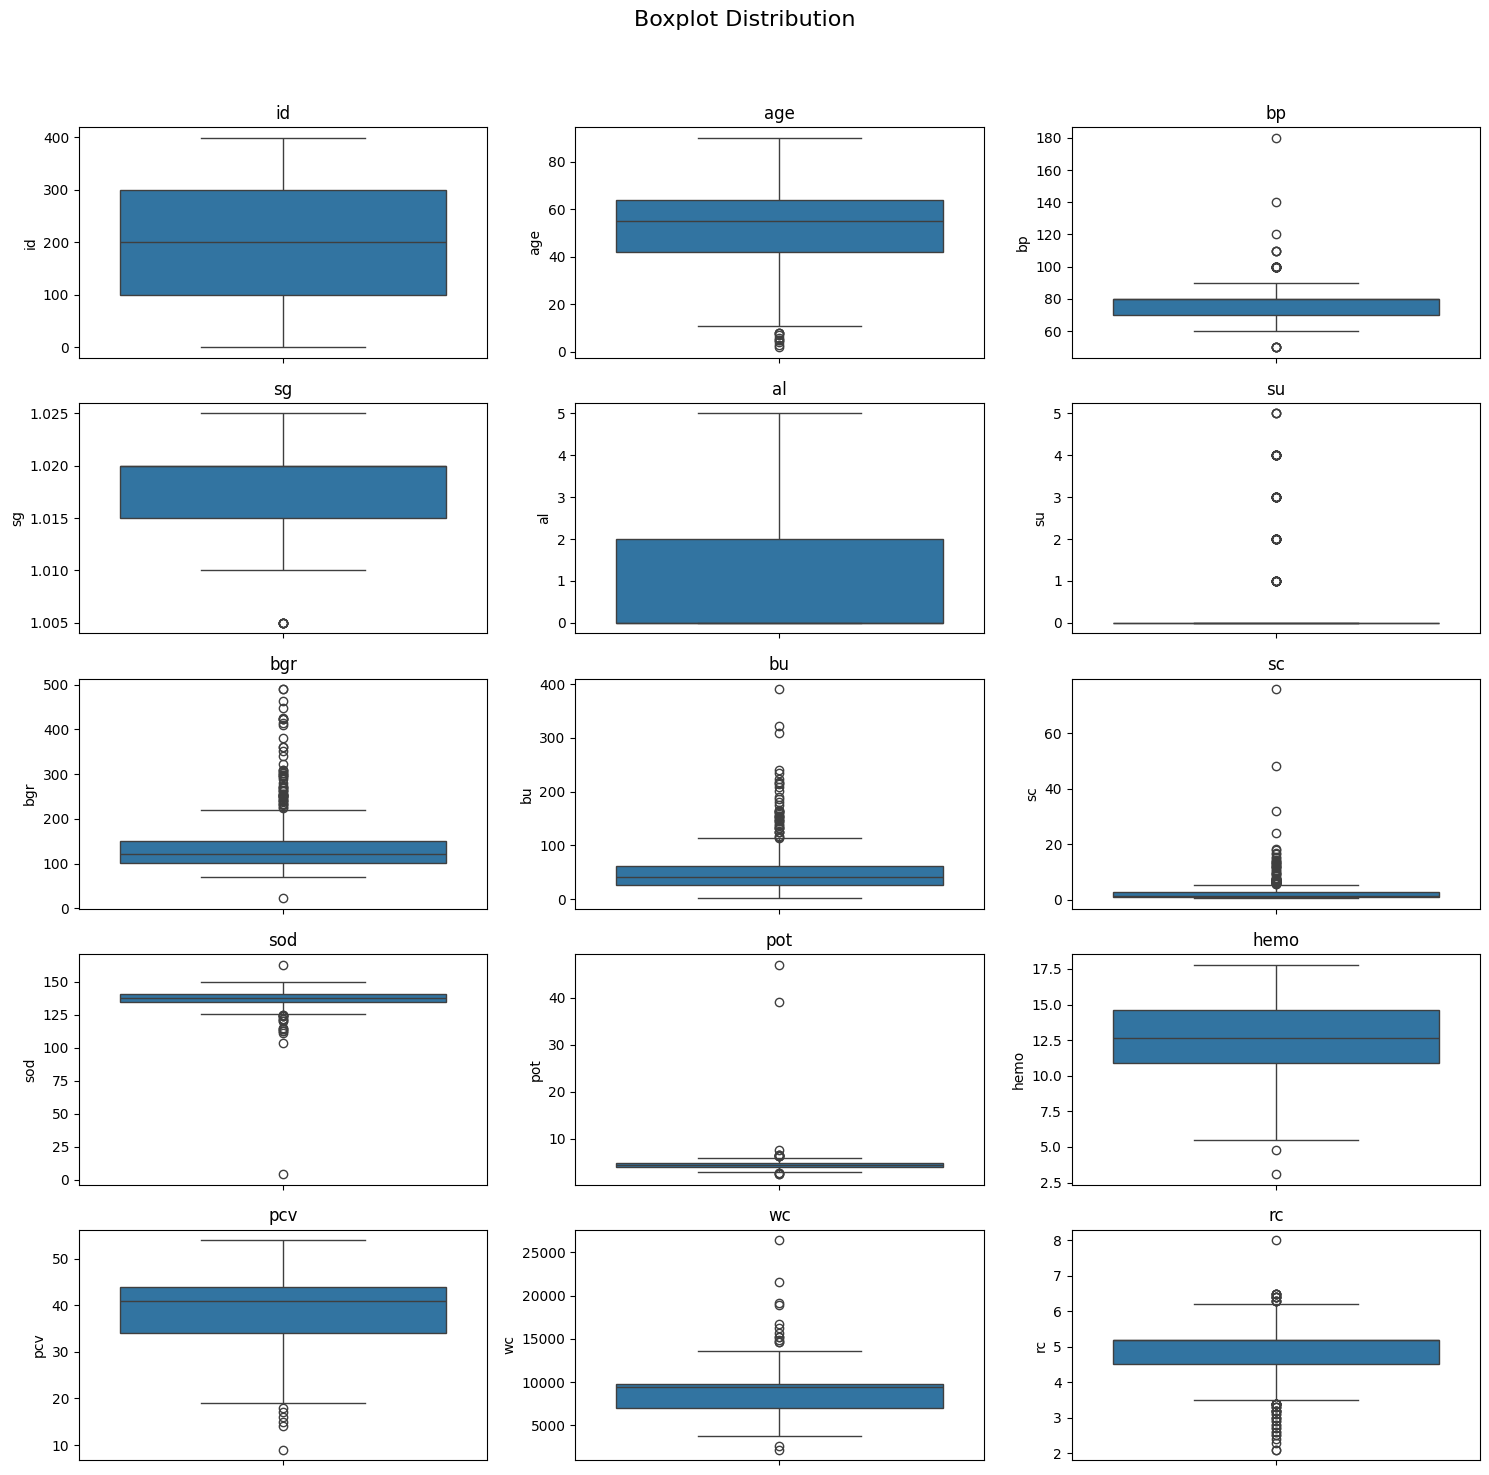

In [114]:
boxplot(df_row)

In [144]:
df=pd.concat([df_cols,df_row],axis=1)
df

,rbc,pc,pcc,ba,htn,dm,cad,appet,pe,ane,...,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
0,normal,normal,notpresent,notpresent,yes,yes,no,good,no,no,...,0.0,121.0,36.0,1.2,138.0,4.4,15.4,44.0,7800.0,5.2
1,normal,normal,notpresent,notpresent,no,no,no,good,no,no,...,0.0,121.0,18.0,0.8,138.0,4.4,11.3,38.0,6000.0,5.2
2,normal,normal,notpresent,notpresent,no,yes,no,poor,no,yes,...,3.0,423.0,53.0,1.8,138.0,4.4,9.6,31.0,7500.0,5.2
3,normal,abnormal,present,notpresent,yes,no,no,poor,yes,yes,...,0.0,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9
4,normal,normal,notpresent,notpresent,no,no,no,good,no,no,...,0.0,106.0,26.0,1.4,138.0,4.4,11.6,35.0,7300.0,4.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,normal,normal,notpresent,notpresent,no,no,no,good,no,no,...,0.0,140.0,49.0,0.5,150.0,4.9,15.7,47.0,6700.0,4.9
396,normal,normal,notpresent,notpresent,no,no,no,good,no,no,...,0.0,75.0,31.0,1.2,141.0,3.5,16.5,54.0,7800.0,6.2
397,normal,normal,notpresent,notpresent,no,no,no,good,no,no,...,0.0,100.0,26.0,0.6,137.0,4.4,15.8,49.0,6600.0,5.4
398,normal,normal,notpresent,notpresent,no,no,no,good,no,no,...,0.0,114.0,50.0,1.0,135.0,4.9,14.2,51.0,7200.0,5.9


In [145]:
df.columns

Index(['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane',
       'classification', 'id', 'age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc'],
      dtype='object')

In [146]:
# split the data into independent and dependent variables
x=df.drop('classification',axis=1)
y=df['classification']

In [147]:
x.shape

(400, 25)

In [148]:
y.shape

(400,)

In [149]:
y.value_counts()

classification
ckd       250
notckd    150
Name: count, dtype: int64

In [150]:
def classify(x):
    categorical_column=[]
    for col in x.columns:
        if x[col].dtype=='object':
            if x[col].nunique() < 3:
                categorical_column.append(col)
    return categorical_column 

In [151]:
categorical_column=classify(x)
categorical_column

['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

In [152]:
for i in categorical_column:
    print(x[i].value_counts())
    print()

rbc
normal      353
abnormal     47
Name: count, dtype: int64

pc
normal      324
abnormal     76
Name: count, dtype: int64

pcc
notpresent    358
present        42
Name: count, dtype: int64

ba
notpresent    378
present        22
Name: count, dtype: int64

htn
no     253
yes    147
Name: count, dtype: int64

dm
no     263
yes    137
Name: count, dtype: int64

cad
no     366
yes     34
Name: count, dtype: int64

appet
good    318
poor     82
Name: count, dtype: int64

pe
no     324
yes     76
Name: count, dtype: int64

ane
no     340
yes     60
Name: count, dtype: int64



In [153]:
df_dummies=pd.get_dummies(x[categorical_column],drop_first=True)
df_dummies

,rbc_normal,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_poor,pe_yes,ane_yes
0,True,True,False,False,True,True,False,False,False,False
1,True,True,False,False,False,False,False,False,False,False
2,True,True,False,False,False,True,False,True,False,True
3,True,False,True,False,True,False,False,True,True,True
4,True,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
395,True,True,False,False,False,False,False,False,False,False
396,True,True,False,False,False,False,False,False,False,False
397,True,True,False,False,False,False,False,False,False,False
398,True,True,False,False,False,False,False,False,False,False


In [154]:
df_dummies=np.where(df_dummies[::]==True,1,0)
df_dummies

array([[1, 1, 0, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 0, 0],
       [1, 1, 0, ..., 1, 0, 1],
       ...,
       [1, 1, 0, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 0, 0]], shape=(400, 10))

In [155]:
df_dummies=pd.DataFrame(df_dummies,columns=categorical_column)
df_dummies

,rbc,pc,pcc,ba,htn,dm,cad,appet,pe,ane
0,1,1,0,0,1,1,0,0,0,0
1,1,1,0,0,0,0,0,0,0,0
2,1,1,0,0,0,1,0,1,0,1
3,1,0,1,0,1,0,0,1,1,1
4,1,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
395,1,1,0,0,0,0,0,0,0,0
396,1,1,0,0,0,0,0,0,0,0
397,1,1,0,0,0,0,0,0,0,0
398,1,1,0,0,0,0,0,0,0,0


In [157]:
df = pd.concat([x.drop(columns=categorical_column),df_dummies],axis=1)
df

,id,age,bp,sg,al,su,bgr,bu,sc,sod,...,rbc,pc,pcc,ba,htn,dm,cad,appet,pe,ane
0,0.0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,138.0,...,1,1,0,0,1,1,0,0,0,0
1,1.0,7.0,50.0,1.020,4.0,0.0,121.0,18.0,0.8,138.0,...,1,1,0,0,0,0,0,0,0,0
2,2.0,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,138.0,...,1,1,0,0,0,1,0,1,0,1
3,3.0,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,...,1,0,1,0,1,0,0,1,1,1
4,4.0,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,138.0,...,1,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395.0,55.0,80.0,1.020,0.0,0.0,140.0,49.0,0.5,150.0,...,1,1,0,0,0,0,0,0,0,0
396,396.0,42.0,70.0,1.025,0.0,0.0,75.0,31.0,1.2,141.0,...,1,1,0,0,0,0,0,0,0,0
397,397.0,12.0,80.0,1.020,0.0,0.0,100.0,26.0,0.6,137.0,...,1,1,0,0,0,0,0,0,0,0
398,398.0,17.0,60.0,1.025,0.0,0.0,114.0,50.0,1.0,135.0,...,1,1,0,0,0,0,0,0,0,0


In [162]:
df.drop(columns='id',inplace=True)
df

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,...,rbc,pc,pcc,ba,htn,dm,cad,appet,pe,ane
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,138.0,4.4,...,1,1,0,0,1,1,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,121.0,18.0,0.8,138.0,4.4,...,1,1,0,0,0,0,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,138.0,4.4,...,1,1,0,0,0,1,0,1,0,1
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,...,1,0,1,0,1,0,0,1,1,1
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,138.0,4.4,...,1,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,0.5,150.0,4.9,...,1,1,0,0,0,0,0,0,0,0
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,1.2,141.0,3.5,...,1,1,0,0,0,0,0,0,0,0
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,0.6,137.0,4.4,...,1,1,0,0,0,0,0,0,0,0
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,1.0,135.0,4.9,...,1,1,0,0,0,0,0,0,0,0


In [163]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42, stratify=y)

In [165]:
print(f" x_train shape {x_train.shape}\n x_test shape {x_test.shape}\n y_train shape {y_train.shape}\n y_test shape {y_test.shape}")

 x_train shape (320, 24)
 x_test shape (80, 24)
 y_train shape (320,)
 y_test shape (80,)


In [182]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [198]:
from sklearn.preprocessing import LabelEncoder


le=LabelEncoder()
y_train_enc=le.fit_transform(y_train) 
y_test_enc=le.transform(y_test)


In [200]:
from sklearn.preprocessing import LabelEncoder

# Encode target labels
le=LabelEncoder()
y_train_enc=le.fit_transform(y_train) 
y_test_enc=e.transform(y_test)

# Train models

# LogisticRegression
logit=LogisticRegression().fit(x_train,y_train_enc)
y_pred_lr=logit.predict(x_test)
accuracy_lr =accuracy_score(y_test_enc, y_pred_lr)  


#DecisionTreeClassifier
dtree=DecisionTreeClassifier().fit(x_train, y_train_enc)
y_pred_dt=dtree.predict(x_test)
accuracy_dt=accuracy_score(y_test_enc, y_pred_dt)


#RandomForestClassifier
rforest =RandomForestClassifier().fit(x_train,y_train_enc)
y_pred_rf= rforest.predict(x_test)
accuracy_rf=accuracy_score(y_test_enc,y_pred_rf)

#xgboost
xgboost=XGBClassifier().fit(x_train, y_train_enc)
y_pred_xg =xgboost.predict(x_test)
accuracy_xg=accuracy_score(y_test_enc, y_pred_xg)

#knn
knn =KNeighborsClassifier().fit(x_train, y_train_enc)
y_pred_knn= knn.predict(x_test)
accuracy_knn=accuracy_score(y_test_enc, y_pred_knn)

#svm
svm =SVC().fit(x_train, y_train_enc)
y_pred_svm=svm.predict(x_test)
accuracy_svm=accuracy_score(y_test_enc, y_pred_svm)

#GaussianNB
nbt=GaussianNB().fit(x_train, y_train_enc)
y_pred_nbt=nbt.predict(x_test)
accuracy_nbt=accuracy_score(y_test_enc, y_pred_nbt)

# Voting Classifier
model_evc=VotingClassifier(
    estimators=[('logit', logit), ('dtree', dtree), ('rforest', rforest),
                ('xgboost', xgboost), ('knn', knn), ('svm', svm), ('nbt', nbt)],
    voting='hard'
).fit(x_train, y_train_enc)

pred_evc=model_evc.predict(x_test)
accuracy_evc=accuracy_score(y_test_enc, pred_evc)


NameError: name 'e' is not defined

      Method Used  Accuracy
0  LogitRegession    0.8625
1           Dtree    0.9625
2         RForest    0.9875
3             XGB    0.9500
4             KNN    0.6000
5             SVM    0.6000
6             NBT    0.9750
7          Voting    0.9500
Axes(0.125,0.11;0.775x0.77)


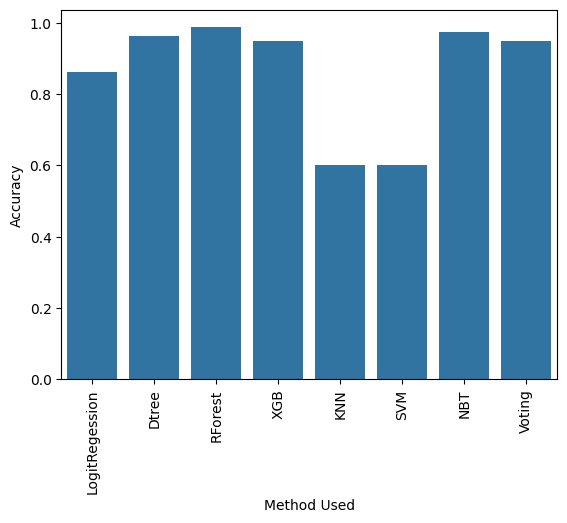

In [186]:
list1=['LogitRegession','Dtree','RForest','XGB','KNN','SVM','NBT','Voting']
list2=[accuracy_lr,accuracy_dt,accuracy_rf,accuracy_xg,accuracy_knn,accuracy_svm,accuracy_nbt,accuracy_evc]
list3=[logit,dtree,rforest,xgboost,knn,svm,nbt,model_evc]

df_accuracy=pd.DataFrame({"Method Used":list1, "Accuracy":list2})

print(df_accuracy)

chart=sns.barplot(x="Method Used", y="Accuracy", data=df_accuracy)
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
print(chart)   

In [190]:
# Predictions
pred_evc_train=model_evc.predict(x_train)
pred_evc_test=model_evc.predict(x_test)

# Use encoded labels for accuracy
accuracy_evc_train=accuracy_score(y_train_enc,pred_evc_train)
accuracy_evc_test=accuracy_score(y_test_enc, pred_evc_test)

print("************************")
print("Training Accuracy :", accuracy_evc_train)
print("************************")
print("Test Accuracy :", accuracy_evc_test)


************************
Training Accuracy : 1.0
************************
Test Accuracy : 0.95


In [191]:
from sklearn.model_selection import cross_val_score
training=cross_val_score(model_evc, x_train, y_train, cv=10)
print("Training Accuracy :", training.mean())
print("***************")
print("Testb Accuracy :",accuracy_evc_test)

Training Accuracy : 0.984375
***************
Testb Accuracy : 0.95


In [194]:
from sklearn.metrics import classification_report

# Predictions
pred_evc_train=model_evc.predict(x_train)
pred_evc_test=model_evc.predict(x_test)

# Use encoded labels for evaluation
print("************************")
print("Training Classification Report:")
print(classification_report(y_train_enc, pred_evc_train))
print("************************")
print("Test Classification Report:")
print(classification_report(y_test_enc, pred_evc_test))


************************
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       120

    accuracy                           1.00       320
   macro avg       1.00      1.00      1.00       320
weighted avg       1.00      1.00      1.00       320

************************
Test Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        50
           1       0.96      0.90      0.93        30

    accuracy                           0.95        80
   macro avg       0.95      0.94      0.95        80
weighted avg       0.95      0.95      0.95        80



In [195]:
from sklearn.metrics import confusion_matrix

print("************************")
print("Training Confusion Matrix:")
print(confusion_matrix(y_train_enc, pred_evc_train))
print("************************")
print("Test Confusion Matrix:")
print(confusion_matrix(y_test_enc, pred_evc_test))


************************
Training Confusion Matrix:
[[200   0]
 [  0 120]]
************************
Test Confusion Matrix:
[[49  1]
 [ 3 27]]


In [197]:
import joblib

# Save the model
joblib.dump(model_evc, "ckd_voting_model.pkl")

# Save the label encoder
joblib.dump(le, "label_encoder.pkl")


['label_encoder.pkl']